Features used: ['TG', 'W', 'L', 'SV', 'G', 'GS', 'IP', 'K/9', 'BB/9', 'HR/9', 'BABIP', 'LOB%', 'GB%', 'HR/FB', 'vFA (pi)', 'FIP', 'xFIP', 'WAR', 'RunDiff', 'WinPct']

Median ERA used for label: 4.049
Accuracy: 0.885

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89        48
           1       0.91      0.85      0.88        48

    accuracy                           0.89        96
   macro avg       0.89      0.89      0.89        96
weighted avg       0.89      0.89      0.89        96



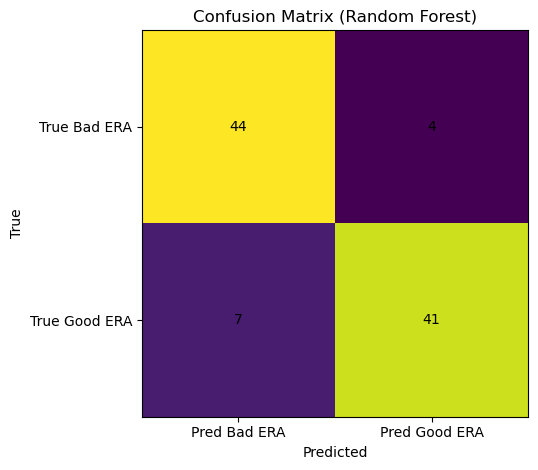

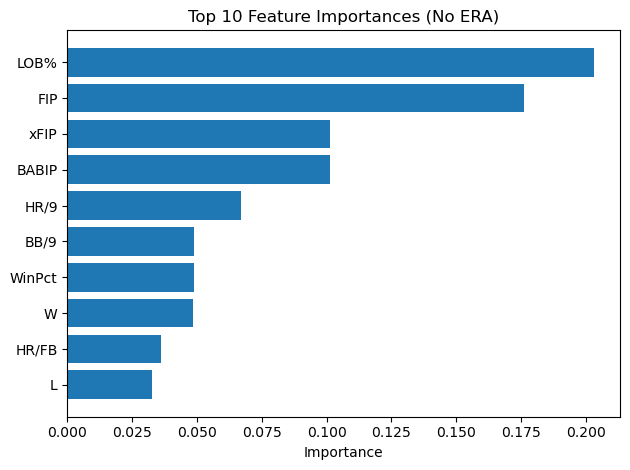

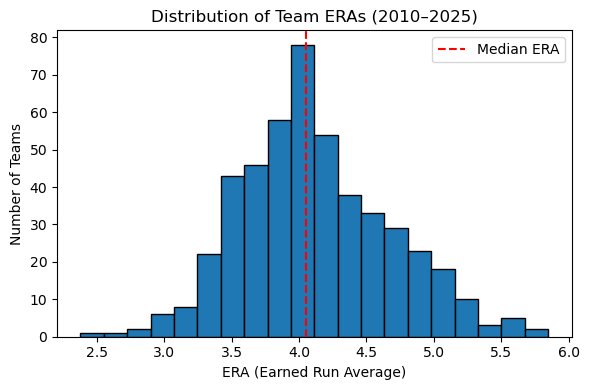

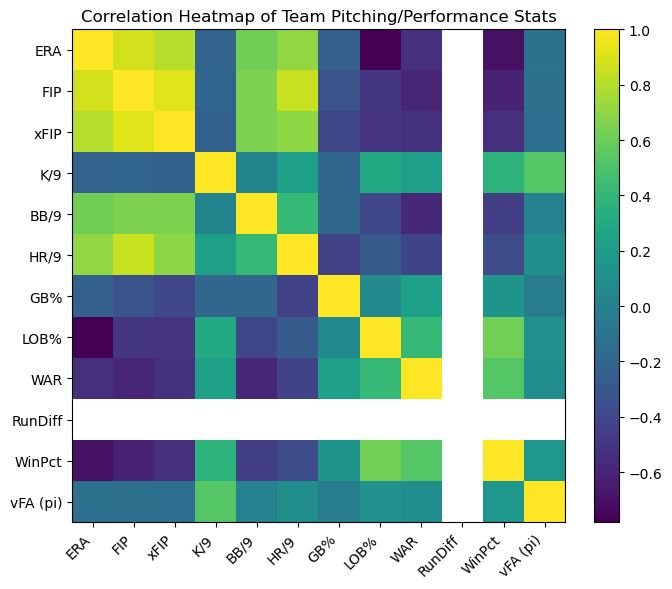

In [ ]:
# GOOD ERA vs BAD ERA CLASSIFICATION MODEL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Load the dataset
df = pd.read_csv(r"C:\Users\nickj\Downloads\Team stats 2010-2025.csv")

# 2) Drop columns that are completely empty
df = df.dropna(axis=1, how="all")

# 3) Create the target variable
median_era = df["ERA"].median()
df["Good_ERA"] = (df["ERA"] <= median_era).astype(int)

# 4) Add simple helper features that might relate to ERA
if {"R", "RA"}.issubset(df.columns):
    df["RunDiff"] = df["R"] - df["RA"]
else:
    df["RunDiff"] = 0.0

df["WinPct"] = df["W"] / (df["W"] + df["L"])

# 5) Choose input features (X) and the target (y)
drop_cols = [c for c in ["Team", "Season", "ERA"] if c in df.columns]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c not in drop_cols + ["Good_ERA"]]

X = df[feature_cols].copy()
y = df["Good_ERA"].copy()

# 6) Replace infinite values with NaN and fill NaN with median values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# 7) Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8) Train a simple Random Forest model
rf = RandomForestClassifier(n_estimators=400, random_state=42)
rf.fit(X_train, y_train)

# 9) Make predictions
y_pred = rf.predict(X_test)

# 10) Evaluate results
acc = accuracy_score(y_test, y_pred)
print("Features used:", feature_cols)
print("\nMedian ERA used for label:", round(median_era, 3))
print("Accuracy:", round(acc, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# 11) Confusion matrix: shows correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Random Forest)")
plt.xticks([0, 1], ["Pred Bad ERA", "Pred Good ERA"])
plt.yticks([0, 1], ["True Bad ERA", "True Good ERA"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 12) Show top 10 most important features (what drives Good ERA)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top = importances.head(10)

plt.figure()
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top 10 Feature Importances (No ERA)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Plot histogram of ERA values
plt.figure(figsize=(6,4))
plt.hist(df["ERA"], bins=20, edgecolor="black")
plt.axvline(df["ERA"].median(), color="red", linestyle="--", label="Median ERA")
plt.title("Distribution of Team ERAs (2010–2025)")
plt.xlabel("ERA (Earned Run Average)")
plt.ylabel("Number of Teams")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap

# Pick pitching features to show in heatmap
want = [
    "ERA", "FIP", "xFIP", "K/9", "BB/9", "HR/9",
    "GB%", "LOB%", "WAR", "RunDiff", "WinPct", "vFA (pi)"
]
# Keep existing columns
cols = [c for c in want if c in df.columns]

# Drop rows 
num = df[cols].replace([np.inf, -np.inf], np.nan).dropna(how="all")
corr = num.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
im = plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Heatmap of Team Pitching/Performance Stats")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


